In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

df = pd.read_csv('dataset.csv')

print(df.head())

  country_code    art_id  rating                       title  \
0           us  60518330       5           Gorgeous pendant    
1           us    422854       1         Bin stopped closing   
2           au  70420205       5         Functional & useful   
3           us  50353607       1  Not The Quality I expected   
4           ca  40415465       5           Very nice product   

                                                text lang_code  \
0  Saw online and had to go see in store…wow! Thi...        en   
1  I bought this trash bin about a year ago and t...        en   
2  This unit won't rank for beauty, but it works ...        en   
3  People. IKEA is known for good product value. ...        en   
4  Easy to assemble. Parts well package to avoid ...        en   

           inserted_on  
0  2024-01-30 15:02:53  
1  2024-01-27 06:05:13  
2  2023-12-14 06:00:42  
3  2024-01-26 03:03:07  
4  2024-01-23 11:42:17  


In [3]:
# Check for missing values in 'country_code'
missing_values = df['country_code'].isnull().sum()
print(f"Missing values in 'country_code': {missing_values}")

# Count the occurrence of each country code
country_code_counts = df['country_code'].value_counts()
print("\nCount of each country code:")
print(country_code_counts)

# Percentage of each country code
country_code_percentage = df['country_code'].value_counts(normalize=True) * 100
print(f"\nPercentage of each country code: {country_code_percentage}")

# Check for unique country codes and their number
unique_country_codes = df['country_code'].unique()
print(f"\nUnique country codes: {unique_country_codes}")
print(f"Number of unique country codes: {len(unique_country_codes)}")

Missing values in 'country_code': 0

Count of each country code:
country_code
us    461888
au    295804
ca    240173
gb    154368
in     35046
es      4833
ie      3901
nl      3590
ch      2024
jp      1187
cz       400
pt       393
kr       243
be         3
Name: count, dtype: int64

Percentage of each country code: country_code
us    38.367475
au    24.571439
ca    19.950359
gb    12.822828
in     2.911153
es     0.401461
ie     0.324043
nl     0.298209
ch     0.168127
jp     0.098600
cz     0.033227
pt     0.032645
kr     0.020185
be     0.000249
Name: proportion, dtype: float64

Unique country codes: ['us' 'au' 'ca' 'gb' 'in' 'ie' 'nl' 'es' 'cz' 'jp' 'ch' 'pt' 'kr' 'be']
Number of unique country codes: 14


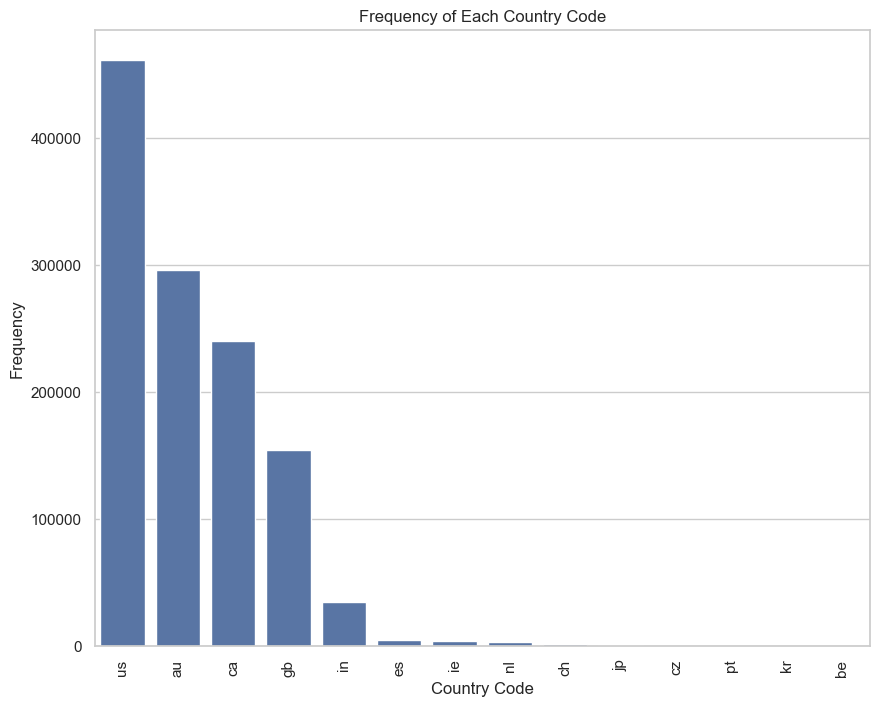

In [4]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='country_code', order = df['country_code'].value_counts().index)
plt.title('Frequency of Each Country Code')
plt.ylabel('Frequency')
plt.xlabel('Country Code')
plt.xticks(rotation=90)
plt.show()

Number of unique 'art_id's: 73734

Repetition counts for 'art_id's:
art_id
17228340    2655
10374923    2469
10308626    2049
50097995    1866
70354309    1832
Name: count, dtype: int64

Descriptive statistics for the repetition of 'art_id's:
count    73734.000000
mean        16.326973
std         53.283034
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
max       2655.000000
Name: count, dtype: float64

Most frequent 'art_id': 17228340 (Repeats 2655 times)
Least frequent 'art_id': 60190097 (Repeats 1 times)


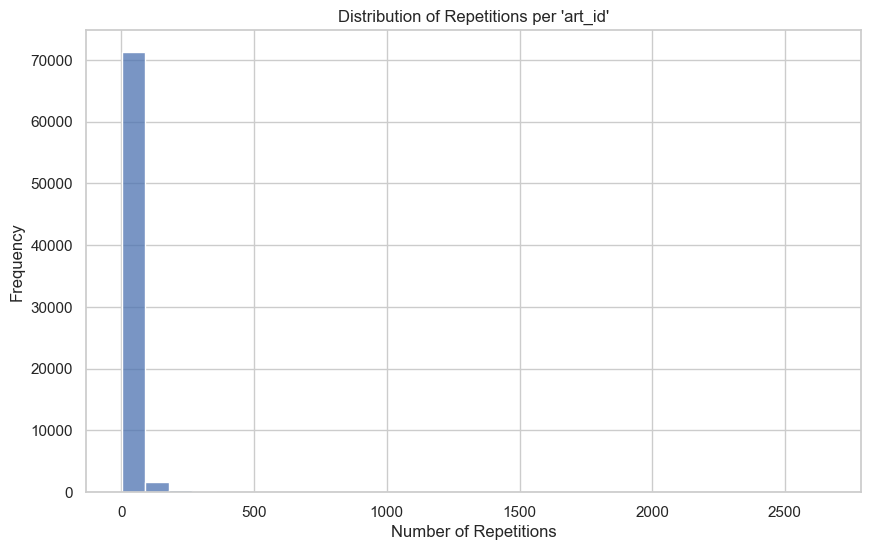

/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_29276/8642461.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='art_id', y='frequency', data=top_art_ids, palette='viridis')


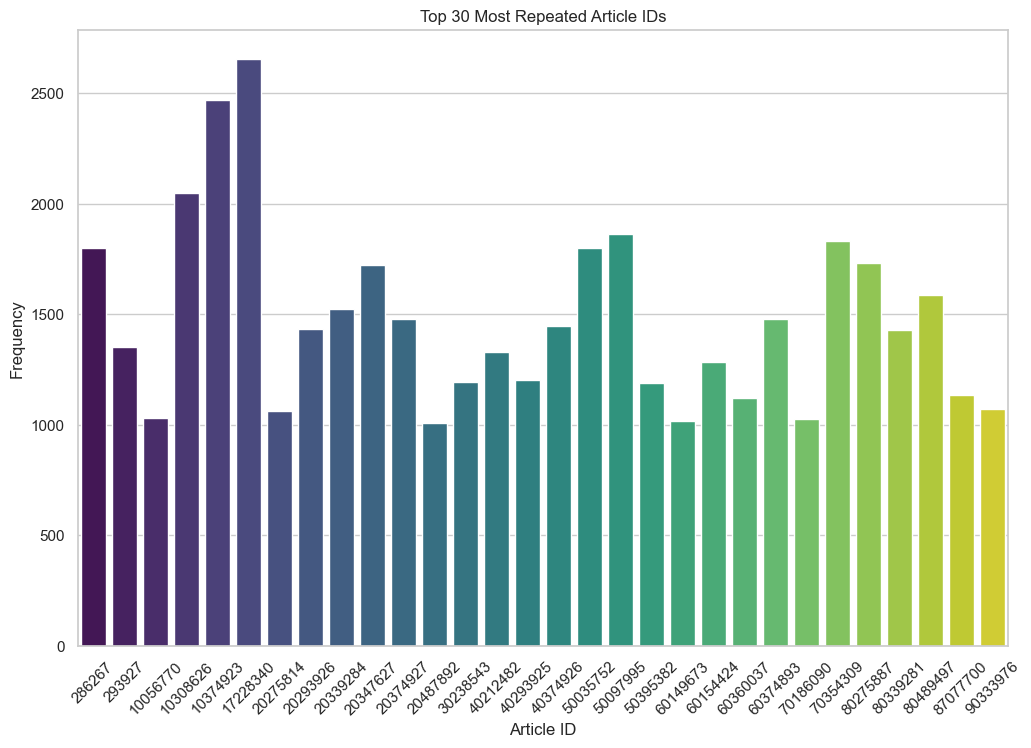

In [5]:
# 1. Count of Unique Values
unique_art_ids = df['art_id'].nunique()
print(f"Number of unique 'art_id's: {unique_art_ids}")

# 2. Frequency of Repetition
art_id_counts = df['art_id'].value_counts()

# Display some of the repetition counts
print("\nRepetition counts for 'art_id's:")
print(art_id_counts.head()) 

# 3. Descriptive Statistics
print("\nDescriptive statistics for the repetition of 'art_id's:")
print(art_id_counts.describe())

# 4. Most and Least Frequent 'art_id's
most_frequent_art_id = art_id_counts.idxmax()
least_frequent_art_id = art_id_counts.idxmin()
print(f"\nMost frequent 'art_id': {most_frequent_art_id} (Repeats {art_id_counts.max()} times)")
print(f"Least frequent 'art_id': {least_frequent_art_id} (Repeats {art_id_counts.min()} times)")

# 5. Histogram of Repetitions
plt.figure(figsize=(10, 6))
sns.histplot(art_id_counts, bins=30, kde=False)
plt.title("Distribution of Repetitions per 'art_id'")
plt.xlabel('Number of Repetitions')
plt.ylabel('Frequency')
plt.show()

# Calculate the frequency of each article ID
art_id_counts = df['art_id'].value_counts().reset_index()
art_id_counts.columns = ['art_id', 'frequency']
art_id_counts = art_id_counts.sort_values(by='frequency', ascending=False)
# Select the top N article IDs to plot for clarity
top_n = 30
top_art_ids = art_id_counts.head(top_n)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='art_id', y='frequency', data=top_art_ids, palette='viridis')
plt.title(f'Top {top_n} Most Repeated Article IDs')
plt.xticks(rotation=45)
plt.xlabel('Article ID')
plt.ylabel('Frequency')
plt.show()

Descriptive Statistics for Ratings:
 count    1.203853e+06
mean     4.533249e+00
std      1.007858e+00
min      1.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Mode: 5


/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_29276/3940224356.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


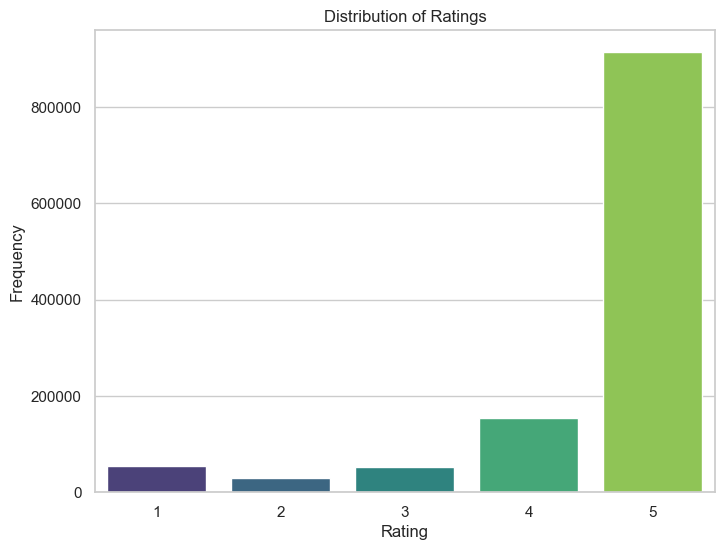

/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_29276/3940224356.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='rating', data=df, palette='coolwarm', inner='quartile')


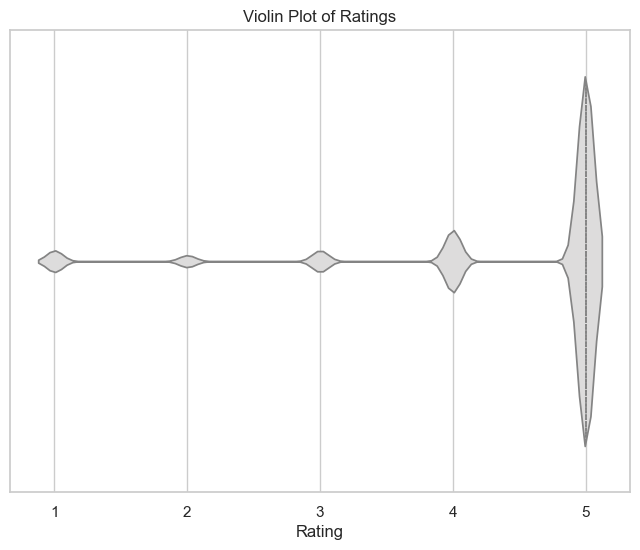

In [6]:
# 1. Descriptive Statistics
rating_description = df['rating'].describe()
print("Descriptive Statistics for Ratings:\n", rating_description)

# Additional statistics - mode
rating_mode = df['rating'].mode()[0]
print(f"\nMode: {rating_mode}")

# 2. Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='rating', data=df, palette='coolwarm', inner='quartile')
plt.title('Violin Plot of Ratings')
plt.xlabel('Rating')
plt.xticks(range(1, 6), [1, 2, 3, 4, 5])  # Ensuring the x-ticks cover the rating range from 1 to 5
plt.show()

Most common words in titles:
great: 170016
good: 104326
for: 101900
and: 90135
the: 79263
perfect: 68253
love: 65623
very: 54498
to: 49870
nice: 46309


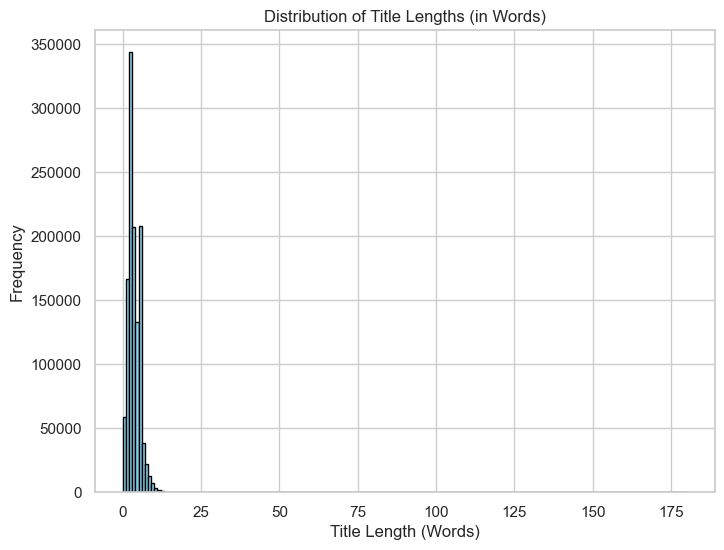

Length of the shortest title: 0 words
Length of the longest title: 180 words


In [16]:
# 1. Word Frequency Count
# Tokenize the titles into words; for simplicity, this example just splits by spaces and assumes lowercasing
words = df['title'].str.lower().str.split(expand=True).stack()
word_counts = Counter(words)
most_common_words = word_counts.most_common(10)
print("Most common words in titles:")
for word, count in most_common_words:
    print(f"{word}: {count}")

# 2. Title Length Distribution (in words)
title_lengths = df['title'].fillna('').str.split().apply(len)
plt.figure(figsize=(8, 6))
plt.hist(title_lengths, bins=range(min(title_lengths), max(title_lengths) + 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Title Lengths (in Words)')
plt.xlabel('Title Length (Words)')
plt.ylabel('Frequency')
plt.show()

# Printing the length of the shortest and longest title
print(f"Length of the shortest title: {title_lengths.min()} words")
print(f"Length of the longest title: {title_lengths.max()} words")

In [17]:
# Calculate the mean, median, and mode of review lengths
mean_length =  title_lengths.mean()
median_length = title_lengths.median()
mode_length = title_lengths.mode()

# Print the results
print(f"Average title length (Mean): {mean_length} words")
print(f"Median title length: {median_length} words")
print(f"Mode of title length: {mode_length.iloc[0]} words") 

Average title length (Mean): 3.053985827173251 words
Median title length: 3.0 words
Mode of title length: 2 words


Most common words in titles:
the: 1148022
and: 858926
to: 705933
i: 683662
a: 588306
it: 520065
for: 498891
is: 347008
this: 346029
of: 321587


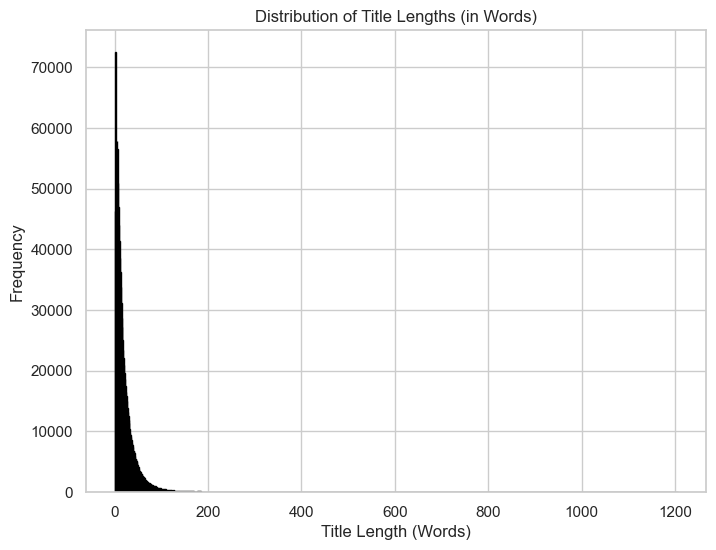

Length of the shortest title: 0 words
Length of the longest title: 1207 words


In [10]:
# 1. Word Frequency Count
# Tokenize the titles into words; for simplicity, this example just splits by spaces and assumes lowercasing
words = df['text'].str.lower().str.split(expand=True).stack()
word_counts = Counter(words)
most_common_words = word_counts.most_common(10)
print("Most common words in reviews:")
for word, count in most_common_words:
    print(f"{word}: {count}")

# 2. Title Length Distribution (in words)
title_lengths = df['text'].fillna('').str.split().apply(len)
plt.figure(figsize=(8, 6))
plt.hist(title_lengths, bins=range(min(title_lengths), max(title_lengths) + 1), color='skyblue', edgecolor='black')
plt.title('Distribution of review Lengths (in Words)')
plt.xlabel('Title Length (Words)')
plt.ylabel('Frequency')
plt.show()

# Printing the length of the shortest and longest title
print(f"Length of the shortest review: {title_lengths.min()} words")
print(f"Length of the longest review: {title_lengths.max()} words")

In [14]:
# Calculate the mean, median, and mode of review lengths
mean_length =  title_lengths.mean()
median_length = title_lengths.median()
mode_length = title_lengths.mode()

print(f"Average review length (Mean): {mean_length} words")
print(f"Median review length: {median_length} words")
print(f"Mode of review length: {mode_length.iloc[0]} words") 

Average review length (Mean): 21.138540170602226 words
Median review length: 13.0 words
Mode of review length: 2 words


In [11]:
# 1. Analysis of 'lang_code'
# Verify lang_code values and count occurrences
lang_code_counts = df['lang_code'].value_counts()
print("Language code counts:")
print(lang_code_counts)

# Check for any unexpected lang_codes
expected_lang_codes = ['en']  # Add any other expected lang_codes if necessary
unexpected_lang_codes = df[~df['lang_code'].isin(expected_lang_codes)]['lang_code'].unique()
if len(unexpected_lang_codes) > 0:
    print("Unexpected language codes found:", unexpected_lang_codes)
else:
    print("All language codes are as expected.")

Language code counts:
lang_code
en    1203853
Name: count, dtype: int64
All language codes are as expected.


Earliest date: 2022-09-01 02:00:35
Latest date: 2024-02-19 09:04:13


/var/folders/2k/rtm_6np11m34j4lvs1m7tpyr0000gp/T/ipykernel_29276/996445816.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('inserted_on').resample('M').size().plot()


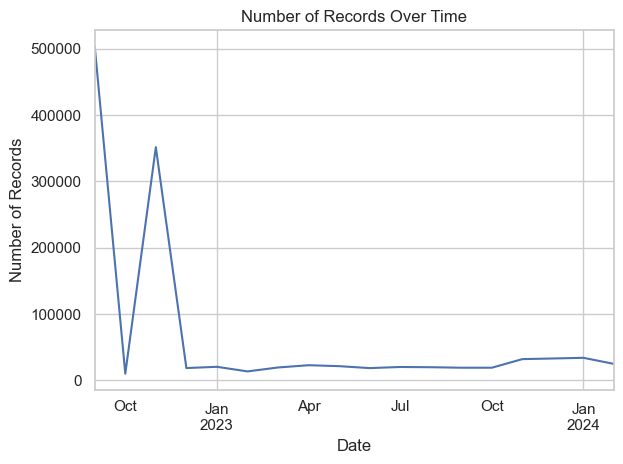

In [12]:
# 2. Analysis of 'date' feature
# Convert 'date' column to datetime format if it's not already
df['inserted_on'] = pd.to_datetime(df['inserted_on'])

# Summarize the date range
print(f"Earliest date: {df['inserted_on'].min()}")
print(f"Latest date: {df['inserted_on'].max()}")

# Visualization: Number of records over time (by month/year)
# This example groups by month, adjust the 'freq' parameter as needed (e.g., 'Y' for year)
df.set_index('inserted_on').resample('M').size().plot()
plt.title('Number of Records Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()